<a href="https://colab.research.google.com/github/daf01-web/Mineria-de-Datos/blob/main/1Parcial_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Práctica No. 3**

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# Leer archivo
df = pd.read_excel("/Datos.xlsx")

# Normalizar valores faltantes
df = df.replace(["Nan", "nan", "NA", ""], pd.NA)

# Convertir columnas numéricas
cols_nums = ["Edad (años)", "Peso (Kg)", "Glucosa (mmol/L)",
             "Presión (mmHg)", "Estatura (cm)", "Colesterol (mg/dl)"]

for col in cols_nums:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Normalizar Género
df["Género"] = df["Género"].replace({"M":"Masculino", "F":"Femenino", "B":"Otro"})
df["Género"] = df["Género"].fillna("Otro")

# Imputar de valores faltantes en numéricos
for col in cols_nums:
    df[col] = df[col].fillna(df[col].median())

# Eliminar filas con demasiados valores faltantes (ej. más del 50%)
df_limpio = df.dropna(thresh=int(df.shape[1]*0.5))

# Eliminar duplicados
df_limpio = df_limpio.drop_duplicates()

# Filtrar edades fuera de rango (0–100 años)
df_limpio = df_limpio[(df_limpio["Edad (años)"] >= 0) & (df_limpio["Edad (años)"] <= 100)]

# Reporte final
total_original = len(df)
total_limpio = len(df_limpio)
descartados = total_original - total_limpio

print(f"\nTotal de registros originales: {total_original}")
print(f"Total de registros limpios: {total_limpio}")
print(f"Total de registros descartados: {descartados}")

# Guardar el archivo limpio
df_limpio.to_excel("Datos_limpios.xlsx", index=False)
print("\nArchivo limpio guardado como 'Datos_limpios.xlsx'")

# Descargar el archivo ya limpio
files.download("Datos_limpios.xlsx")




Total de registros originales: 237
Total de registros limpios: 237
Total de registros descartados: 0

Archivo limpio guardado como 'Datos_limpios.xlsx'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Práctica No. 4**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import files

# Leer archivo limpio
df = pd.read_excel("/content/Datos_limpios_.xlsx")

# Seleccionar columnas numéricas a normalizar
cols_norm = ["Edad (años)", "Peso (Kg)", "Glucosa (mmol/L)", "Presión (mmHg)"]

# Crear el escalador
scaler = StandardScaler()

# Ajustar y transformar los datos
df_scaled = df.copy()
df_scaled[cols_norm] = scaler.fit_transform(df[cols_norm])

# Validación: mostrar primeras filas
print(df_scaled.head())

# Guardar archivo con datos normalizados
df_scaled.to_excel("Datos_normalizados.xlsx", index=False)
print("\nArchivo guardado como 'Datos_normalizados.xlsx'")

# Descargar el archivo ya normalizado
files.download("Datos_normalizados.xlsx")


   Paciente  Edad (años)  Peso (Kg)  Glucosa (mmol/L)  Presión (mmHg) Género  \
0         0    -1.379846   1.452127          0.560312        1.072814      M   
1         1    -0.341990  -0.454393          1.123067       -1.021305      M   
2         2    -1.330424  -0.399921         -0.416634        1.262314      M   
3         3    -0.391412   1.234239         -1.155566        1.612440      M   
4         4    -0.193725   1.288711          0.147676        1.107993      M   

   Estatura (cm)  Colesterol (mg/dl)  
0            136               177.0  
1            169               187.0  
2            150               188.1  
3             73               197.3  
4             79               112.2  

Archivo guardado como 'Datos_normalizados.xlsx'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**SKlearn**

/tmp/ipykernel_39042/1358955676.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_binary500.fillna(method = 'ffill', inplace=True)


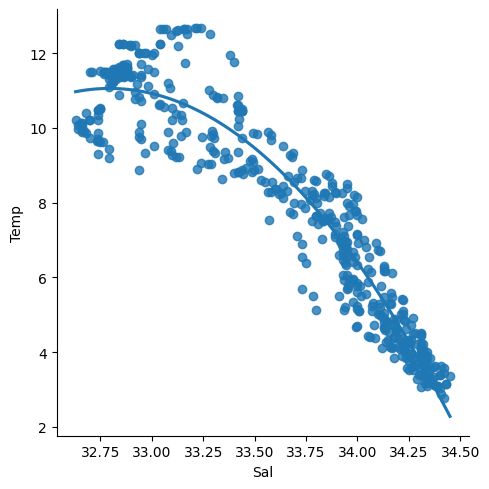

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


df = pd.read_csv('/content/bottle1.csv')
df_binary = df[['Salnty', 'T_degC']]

df_binary.columns = ['Sal','Temp']
df_binary500 = df_binary[:][:500]

df_binary500.fillna(method = 'ffill', inplace=True)
df_binary500.dropna(inplace=True)
sns.lmplot(x='Sal',y='Temp',data=df_binary500,order=2,ci = None)
plt.show()

In [9]:

X = np.array(df_binary500['Sal']).reshape(-1,1)
y = np.array(df_binary500['Temp']).reshape(-1,1)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25)
regr = LinearRegression()
regr.fit(X_train,y_train)
print(regr.score(X_test,y_test))

0.8503458647179913


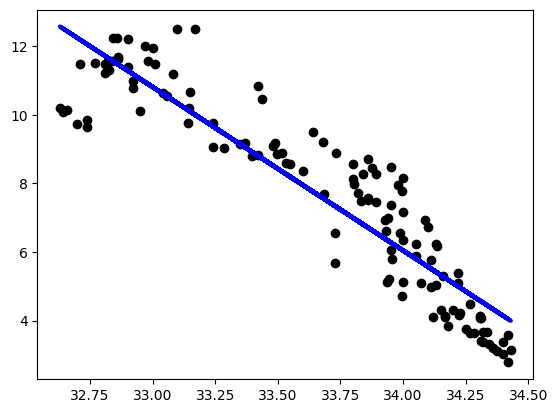

In [10]:
y_pred = regr.predict(X_test)
plt.scatter(X_test,y_test,color='black')
plt.plot(X_test,y_pred,color='blue',linewidth=3)
plt.show()
